# (연구) HST old example (R) 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

### hst를 구현한 함수

`-` 아래는 HST를 구현한 함수입니다. 

In [2]:
hst1d<-function(f,tau,b=sd(f)*0.01,prob=c(1/3,1/3,1/3)) # prob=c(l,c,r)
{
  lprob<-prob[1]
  cprob<-prob[2]
  rprob<-prob[3]
  len<-length(f)
  hstresult<-rep(0,len*tau); dim(hstresult)<-c(len,tau)
  hlen<-round(len/2)
  oldf<-f
  f<-c(f[hlen:1],f,f[len:(len-hlen+1)])
  
  ls<-landshape(f)
  f_before<-f
  f_after<-f*0
  L<-length(f)

  for(i in 1:tau)
  {
    minindex<-which(ls=="minimum")
    maxindex<-which(ls=="maximum")
    incindex<-which(ls=="increasing")
    decindex<-which(ls=="decreasing")
    flatindex<-which(ls=="flat")
    epsilon<-runif(1)*b
    f_after[minindex]<-f_before[minindex]+epsilon+epsilon*lprob+epsilon*rprob
    f_after[maxindex]<-f_before[maxindex]+epsilon*cprob
    f_after[incindex]<-f_before[incindex]+epsilon*(cprob+rprob)+epsilon*(lprob)
    f_after[decindex]<-f_before[decindex]+epsilon*(cprob+lprob)+epsilon*(rprob)
    f_after[flatindex]<-f_before[flatindex]+epsilon*cprob+epsilon*rprob*0.5+epsilon*lprob*0.5
    ls<-landshape(f_after)
    f_before<-f_after
    hstresult[,i]<-f_after[(hlen+1):(L-hlen)]
  }
  cbind(oldf,hstresult)
}

landshape<-function(f)
{
  len<-length(f)
  ls<-f*0
  ls[c(1,len)]<-"flat"
  for(i in 2:(len-1))
  {
    if((f[i]>f[i-1])&(f[i]<f[i+1])) ls[i]<-"increasing"
    else if((f[i]<f[i-1])&(f[i]>f[i+1])) ls[i]<-"decreasing"
    else if(mean(c(f[i-1],f[i+1]))<f[i]) ls[i]<-"maximum"
    else if(mean(c(f[i-1],f[i+1]))>f[i]) ls[i]<-"minimum"
    else ls[i]<-"flat"
  }
  ls
}

### TEST DATA

In [3]:
seq1<-c(1,2,3,2);
f1<-c(rep(seq1,33),1);
localstr<-landshape(f1)
localstr[1]<-"minimum"
localstr[133]<-"minimum"
f2<-c(1:23,22:2,1:23,22:2,1:23,22:2,1)/2 # trend 
globalstr<-landshape(f2)
globalstr[1]<-"minimum"
globalstr[133]<-"minimum" 

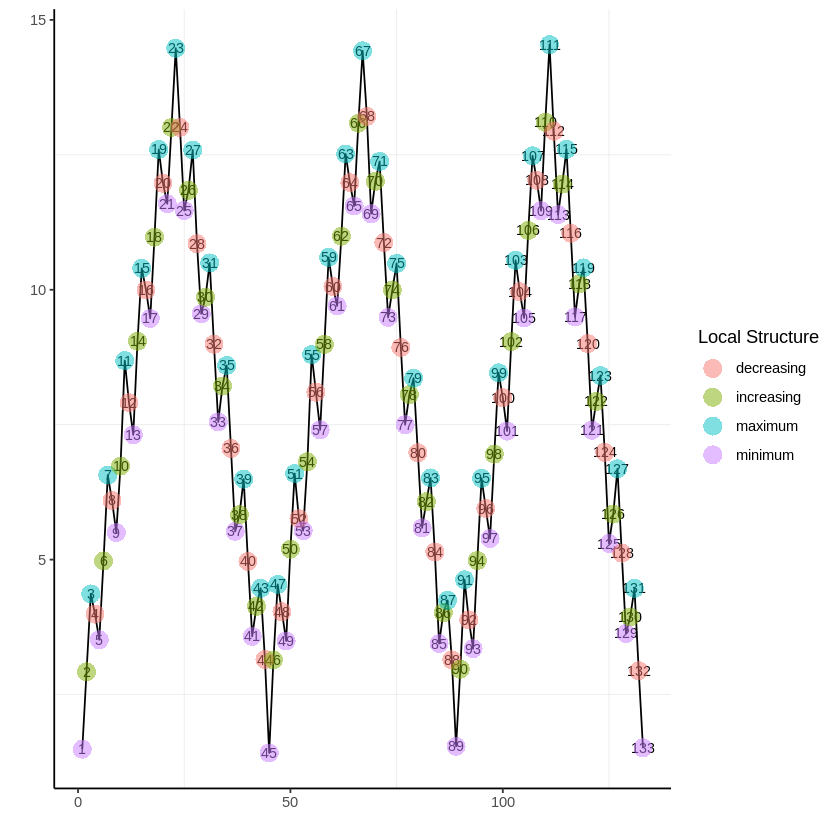

In [11]:
f<-f1+f2 
f<-f+rnorm(length(f),0,sd=0.1)

data_multiscalegrouping<-data.frame(localstr=localstr,globalstr=globalstr,f=f)
library(ggplot2)
### Data description
ggplot(data_multiscalegrouping, aes(x=1:length(f), y=f,label=1:133))+ geom_text(size=3)+geom_line()+ 
    geom_point(aes(x=1:length(f), y=f, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")

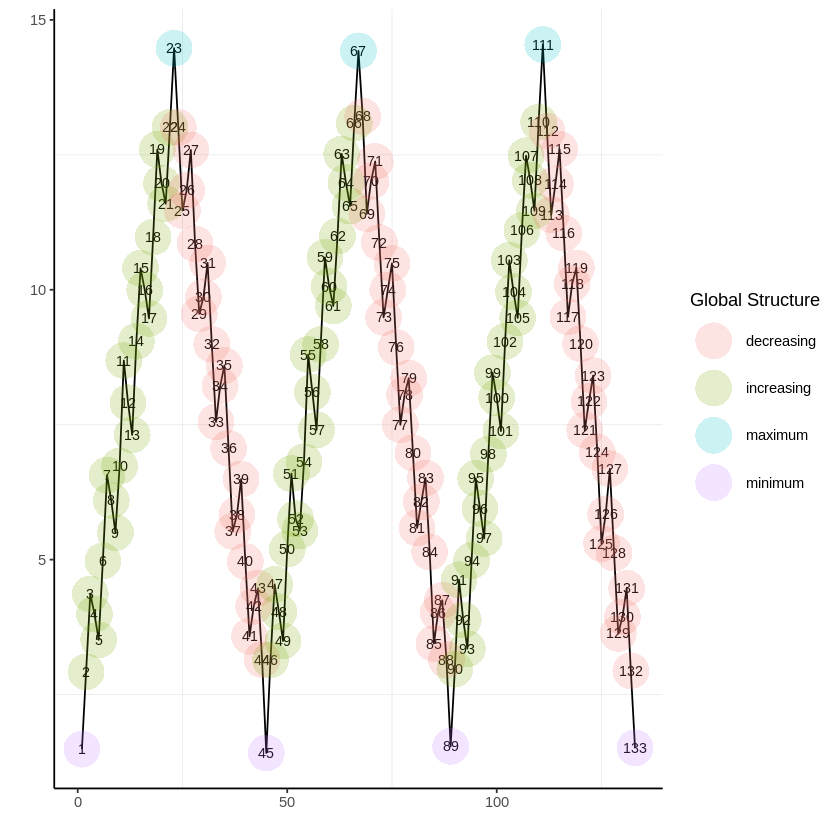

In [12]:
ggplot(data_multiscalegrouping, aes(x=1:length(f), y=f,label=1:133))+ geom_text(size=3) + geom_line()+ 
    geom_point(aes(x=1:length(f), y=f, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")

In [14]:
### hst result 
hst1d_rslt<-hst1d(f,b=sd(f)*0.05,tau=130,prob=c(1/3,1/3,1/3))

PC5<-princomp(hst1d_rslt[,1:5])
PC5plotdf<-data.frame(PC1=PC5$score[,1],PC2=PC5$score[,2],
                      localstr=localstr,globalstr=globalstr)
  
PC15<-princomp(hst1d_rslt[,1:15])
PC15plotdf<-data.frame(PC1=PC15$score[,1],PC2=PC15$score[,2],
                       localstr=localstr,globalstr=globalstr)
  
PC30<-princomp(hst1d_rslt[,1:30])
PC30plotdf<-data.frame(PC1=PC30$score[,1],PC2=PC30$score[,2],
                       localstr=localstr,globalstr=globalstr)        
  
PC60<-princomp(hst1d_rslt[,1:60])
PC60plotdf<-data.frame(PC1=PC60$score[,1],PC2=PC60$score[,2],
                       localstr=localstr,globalstr=globalstr)
  
PC90<-princomp(hst1d_rslt[,1:90])
PC90plotdf<-data.frame(PC1=PC90$score[,1],PC2=PC90$score[,2],
                       localstr=localstr,globalstr=globalstr)
  
PC120<-princomp(hst1d_rslt[,1:120])
PC120plotdf<-data.frame(PC1=PC120$score[,1],PC2=PC120$score[,2],
                        localstr=localstr,globalstr=globalstr)


In [20]:
## plot 
library(gridExtra)
local5<-ggplot(PC5plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",5)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
local15<-ggplot(PC15plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",15)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
local30<-ggplot(PC30plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",30)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  

local60<-ggplot(PC60plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",60)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))

  
local90<-ggplot(PC90plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",90)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))

local120<-ggplot(PC120plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=localstr),size=5,alpha=0.5,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Local Structure")+
    ggtitle(expression(paste(tau,"=",120)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))


#### global 
global5<-ggplot(PC5plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",5)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
global15<-ggplot(PC15plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",15)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
global30<-ggplot(PC30plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",30)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
global60<-ggplot(PC60plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",60)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
  
global90<-ggplot(PC90plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",90)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))
  
global120<-ggplot(PC120plotdf, aes(x=PC1, y=PC2,label=1:133))+ geom_text(size=3)+
    geom_point(aes(x=PC1, y=PC2, colour=globalstr),size=10,alpha=0.2,shape=16)+
    xlab("")+ylab("")+
    theme_bw()+theme(panel.border=element_blank(),axis.line=element_line(colour="Black"))+
    theme(panel.grid.major=element_blank())+
    labs(colour="Global Structure")+
    ggtitle(expression(paste(tau,"=",120)))+
    theme(plot.title=element_text(size=rel(1.5),lineheight=0.9,face="bold.italic",hjust=0.5))+
    theme(plot.margin = unit(c(3,3,3,3), "mm"))

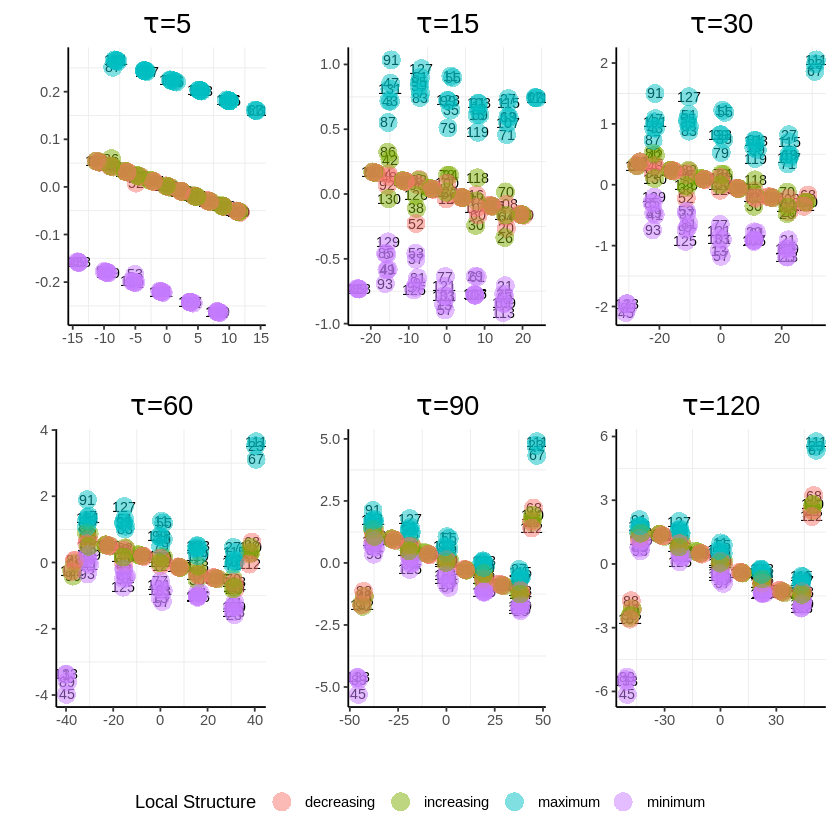

In [18]:
g_legend<-function(a.gplot){
    tmp <- ggplot_gtable(ggplot_build(a.gplot))
    leg <- which(sapply(tmp$grobs, function(x) x$name) == "guide-box")
    legend <- tmp$grobs[[leg]]
    return(legend)}
  
locallegend<-g_legend(local5+ theme(legend.position="bottom"))
globallegend<-g_legend(global5+ theme(legend.position="bottom"))
  
local_dissim<-grid.arrange(arrangeGrob(local5 + theme(legend.position="none"),
                           local15 + theme(legend.position="none"),
                           local30 + theme(legend.position="none"),
                           local60 + theme(legend.position="none"),
                           local90 + theme(legend.position="none"),
                           local120 + theme(legend.position="none"),
                           nrow=2,ncol=3),
                           locallegend, nrow=2,heights=c(10, 1))

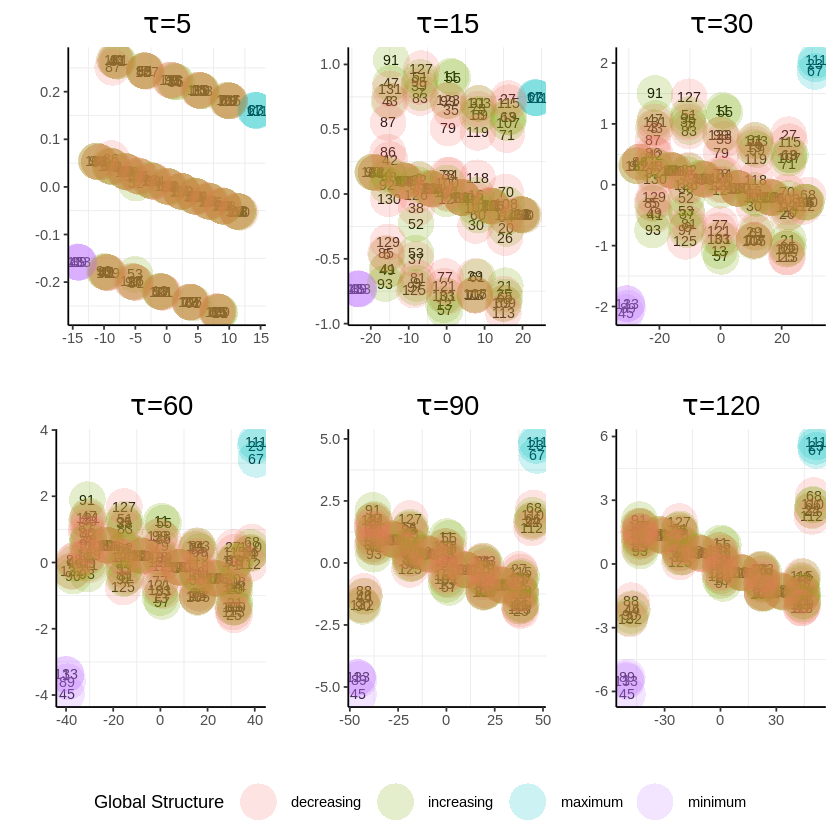

In [19]:
global_dissim<-grid.arrange(arrangeGrob(global5 + theme(legend.position="none"),
                            global15 + theme(legend.position="none"),
                            global30 + theme(legend.position="none"),
                            global60 + theme(legend.position="none"),
                            global90 + theme(legend.position="none"),
                            global120 + theme(legend.position="none"),
                            nrow=2,ncol=3),
                            globallegend, nrow=2,heights=c(10, 1))